# Workshop Agent 1: The Tool-Using Agent

**Workshop:** *10 Essential AI Agents Every Engineer Must Build*  
**Companion Book:** *30 Agents Every AI Engineer Must Build* — Imran Ahmad (Packt Publishing, 2026)  
**Book Reference:** Chapter 7, Sections 7.1–7.3 (pp. 174–186)

---

In this session you will build the foundational pattern on which every later agent in this
workshop is built: an LLM that reasons about a request, selects the right tool from a
registry, and executes it through a function-calling loop. Starting from a natural-language
question about an ad-campaign dataset, the agent runs the full **Think/Plan/Act** cycle —
parsing intent, constructing an execution plan, and invoking guarded tools in sequence.
You will see the agent pick a tool live and return a structured result, rendered as
color-coded log output with charts saved to `outputs/`. You will then stress the
architecture with deliberate failure scenarios — a missing file and a column mismatch —
to observe the layered resilience strategies of Section 7.3 (`@graceful_fallback`, safe
invocation, and clean aborts) first-hand. The notebook runs end-to-end in Simulation Mode;
no API key is required.


In [ ]:
# Google Colab bootstrap — runs only on Colab, no-op everywhere else.
# Locally you are already inside the agent folder with requirements installed.
import os
import sys

if "google.colab" in sys.modules:
    AGENT_DIR = "01-tool-using-agent"
    if not os.path.exists("/content/repo"):
        os.system("git clone --depth 1 https://github.com/cloudanum/ws-10-agents /content/repo")
    os.chdir(f"/content/repo/{AGENT_DIR}")
    %pip install -q -r requirements.txt
    print(f"Colab setup complete — working directory: {os.getcwd()}")
else:
    print("Not on Colab — skipping bootstrap (local setup already in place).")

---
## Section 0: Setup and Configuration

This section loads dependencies, detects the operating mode (Simulation vs. Live),
and initializes the shared infrastructure used by all subsequent sections.

**Key components initialized here:**
- `helpers` package (color logger, resilience decorators, MockLLM)
- `LIVE_MODE` and `INTERACTIVE_MODE` flags
- `AgentError` exception class used by workflow sections

In [1]:
# =============================================================================
# Section 0: Setup and Configuration
# Chapter 7: Tool Manipulation and Orchestration Agents
# Book: "Agents" by Imran Ahmad (Packt, 2026 — B34135)
# =============================================================================

import os
import sys
import json
import time
import getpass
from typing import Dict, Any, List, Tuple, Optional

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Ensure helpers/ is importable from the notebook's working directory
sys.path.insert(0, os.path.abspath("."))

from helpers import (
    log_info, log_success, log_error, log_warning, log_mock, log_step,
    graceful_fallback, safe_invoke,
    MockLLM,
)

# Matplotlib backend for inline rendering
%matplotlib inline

# ---------------------------------------------------------------------------
# Custom Exception — used by workflow sections (Sections 7.7, 7.7b)
# ---------------------------------------------------------------------------
class AgentError(Exception):
    """Raised when a workflow step fails critically and the pipeline must stop."""
    pass

log_info("Core imports complete. helpers package loaded.")

[INFO] Core imports complete. helpers package loaded.


In [2]:
# Multi-provider LLM support (OpenAI / Anthropic / Google Gemini)
# Set LLM_PROVIDER in .env to choose: openai | anthropic | google | auto
# Auto-detection uses the first available key.
# See supporting/llm_provider.py for details.

import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, '..')

try:
    from supporting.llm_provider import detect_provider, get_llm, PROVIDER_MODELS, print_provider_banner
    _PROVIDER, _PROVIDER_KEY, _PROVIDER_MODE = detect_provider()
    print_provider_banner(_PROVIDER, _PROVIDER_MODE)
except ImportError:
    print('[INFO] supporting/llm_provider.py not found — using default OpenAI path')
    _PROVIDER, _PROVIDER_KEY, _PROVIDER_MODE = 'openai', os.getenv('OPENAI_API_KEY'), 'LIVE' if os.getenv('OPENAI_API_KEY') else 'SIMULATION'



   SIMULATION MODE ACTIVE
   Using MockLLM — no API key required



In [3]:
# =============================================================================
# Section 0: API Key Detection and Mode Selection
# Ref: Strategy §3.4 — Simulation Mode Activation Flow
# =============================================================================

# --- Step 1: Try .env file ---
try:
    from dotenv import load_dotenv
    load_dotenv()
    log_info("python-dotenv loaded. Checking .env for OPENAI_API_KEY...")
except ImportError:
    log_warning("python-dotenv not installed. Skipping .env loading.")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()

# --- Step 2: Interactive fallback via getpass ---
# Set False for Colab, CI/CD, nbconvert --execute, or non-interactive envs
INTERACTIVE_MODE = sys.stdin.isatty() if hasattr(sys.stdin, "isatty") else False

if not OPENAI_API_KEY and INTERACTIVE_MODE:
    try:
        OPENAI_API_KEY = getpass.getpass(
            "Enter OpenAI API key (or press Enter to skip): "
        ).strip()
    except (EOFError, OSError, Exception):
        # Catches StdinNotImplementedError, EOFError, and any other input failure
        OPENAI_API_KEY = ""
        INTERACTIVE_MODE = False
        log_warning("Non-interactive environment detected. INTERACTIVE_MODE set to False.")

# --- Step 3: Determine operating mode ---
LIVE_MODE = bool(OPENAI_API_KEY) and "your-key" not in OPENAI_API_KEY and "your_key" not in OPENAI_API_KEY

if LIVE_MODE:
    log_success("LIVE MODE active. LLM calls will use the OpenAI API.")
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
    try:
        from openai import OpenAI
        _openai_client = OpenAI(api_key=OPENAI_API_KEY)
        class LiveLLM:
            """Thin wrapper around OpenAI client matching MockLLM.generate() interface."""
            def generate(self, prompt, **kwargs):
                response = _openai_client.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.7,
                )
                return response.choices[0].message.content
        llm = LiveLLM()
    except Exception as e:
        log_error(f"OpenAI client init failed: {e}. Falling back to Simulation.")
        LIVE_MODE = False
        llm = MockLLM(verbose=True)
else:
    llm = MockLLM(verbose=True)
    log_mock("╔══════════════════════════════════════════════════════════╗")
    log_mock("║  SIMULATION MODE ACTIVE                                 ║")
    log_mock("║  All LLM calls return chapter-derived mock responses.   ║")
    log_mock("║  To use a live API, create .env from .env.template      ║")
    log_mock("╚══════════════════════════════════════════════════════════╝")

# --- Summary ---
log_info(f"Operating Mode: {'LIVE' if LIVE_MODE else 'SIMULATION'}")
log_info(f"Interactive Mode: {INTERACTIVE_MODE}")
log_info(f"Python: {sys.version.split()[0]}")
log_info(f"pandas: {pd.__version__}, matplotlib: {matplotlib.__version__}")

[INFO] python-dotenv loaded. Checking .env for OPENAI_API_KEY...
[MOCK] ╔══════════════════════════════════════════════════════════╗
[MOCK] ║  SIMULATION MODE ACTIVE                                 ║
[MOCK] ║  All LLM calls return chapter-derived mock responses.   ║
[MOCK] ║  To use a live API, create .env from .env.template      ║
[MOCK] ╚══════════════════════════════════════════════════════════╝
[INFO] Operating Mode: SIMULATION
[INFO] Interactive Mode: False
[INFO] Python: 3.14.5
[INFO] pandas: 3.0.5, matplotlib: 3.11.1


---
## Section 1: The Tool-Using Agent

**Chapter Reference:** Section 7.1 — Agents in Action: Tool Invocation Patterns

A Tool-Using agent extends its core reasoning by invoking a predefined set of external
functions. The architecture consists of four primary components (Figure 7.1):

1. **Reasoning Core** — Parses intent and formulates a plan (Think + Plan)
2. **Tool Registry** — Catalog of available tools with metadata and schemas
3. **Execution Engine** — Manages state, retries, and error handling (Act)
4. **Tool Chest** — The collection of guarded functions the agent can execute

This section implements the data visualization assistant's tool chest: four composable
functions that divide the visualization pipeline into clear, testable steps.

#### Figure 7.1 — Internal Architecture of Tool-Using Agents *(Book p. 176)*

```
                                    ┌───────────────────────┐
  User Input ──────────────────────▶│    Reasoning Core     │
  "Show chart"                      │  ┌─────────────────┐  │    3. Pass Plan
                                    │  │ Intent Parsing   │  │───────────────┐
               1. Discover          │  │ Planning         │  │               │
               & Select Tools       │  └─────────────────┘  │               ▼
                    │               └───────────▲───────────┘    ┌─────────────────┐
                    ▼                           │                │ Execution Engine │
           ┌─────────────────┐     2. Return    │                │ State Management │
           │  Tool Registry  │──── Candidates ──┘                │ Error Handling   │
           │  Metadata       │                                   └────────┬────────┘
           │  Schemas        │                                   4. Invoke│Tool
           │  Status         │                                            ▼
           └─────────────────┘                        ┌──────────────────────────────┐
                                                      │        Tool Chest             │
                                                      │  ┌──────────┐ ┌──────────┐   │
                                                      │  │ load_csv │→│plot_chart │   │
                                                      │  └──────────┘ └──────────┘   │
                                                      │  ┌──────────┐ ┌──────────┐   │
                                                      │  │aggregate │ │ validate │   │
                                                      │  └──────────┘ └──────────┘   │
                                                      └──────────────┬───────────────┘
                                                                     ▼
                                                            Generated Chart
```

This architecture cleanly separates decision logic from execution. Explicit schemas make interfaces predictable, while safety wrappers provide resilience. The same structure supports both reactive queries (single tool) and deliberative plans (chained tools).


In [4]:
# =============================================================================
# Section 1: Tool Chest — Four Composable Visualization Functions
# Ref: Section 7.1, pp. 178–179 — Implementation Example
#
# Each function has a single responsibility (single responsibility principle):
#   load_csv         — data ingestion
#   group_by_and_aggregate — data summarization
#   plot_bar_chart   — bar chart rendering
#   plot_line_chart  — line chart rendering
#
# All functions are wrapped with @graceful_fallback for resilience (Section 7.3).
# =============================================================================

# --- Tool 1: Data Ingestion ---
# Ref: Section 7.1, p. 6 — "Handles data ingestion"

@graceful_fallback(fallback_return=pd.DataFrame(), section="7.1")
def load_csv(file_path: str) -> pd.DataFrame:
    """Loads data from a specified CSV file into a pandas DataFrame."""
    df = pd.read_csv(file_path)
    log_step("7.1", 1, f"Loaded {len(df)} rows from '{file_path}'.")
    return df


# --- Tool 2: Data Transformation and Summarization ---
# Ref: Section 7.1, p. 7 — "Performs data transformation and summarization"

@graceful_fallback(fallback_return=None, section="7.1")
def group_by_and_aggregate(
    df: pd.DataFrame,
    group_by_col: str,
    agg_col: str,
    agg_func: str = "sum",
) -> pd.DataFrame:
    """Groups the DataFrame and applies an aggregation function."""
    if group_by_col not in df.columns or agg_col not in df.columns:
        raise ValueError(
            f"Column not found in DataFrame. "
            f"Available: {list(df.columns)}"
        )
    func = {"sum": "sum", "mean": "mean", "count": "count"}.get(agg_func, "sum")
    result = df.groupby(group_by_col)[agg_col].agg(func).reset_index()
    log_step("7.1", 2, f"Grouped '{agg_col}' by '{group_by_col}' using '{func}'.")
    return result


# --- Tool 3: Bar Chart Rendering ---
# Ref: Section 7.1, p. 7 — "Handles final rendering for a bar chart"

@graceful_fallback(fallback_return=None, section="7.1")
def plot_bar_chart(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    title: str,
    output_path: str,
) -> str:
    """Generates and saves a bar chart from the data."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(df[x_col].astype(str), df[y_col], color="#4A90D9")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=100)
    plt.show()
    plt.close(fig)
    log_step("7.1", 3, f"Saved bar chart to '{output_path}'.")
    return output_path


# --- Tool 4: Line Chart Rendering ---
# Ref: Section 7.1, p. 7-8 — "Handles final rendering for a line chart"

@graceful_fallback(fallback_return=None, section="7.1")
def plot_line_chart(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    title: str,
    output_path: str,
) -> str:
    """Generates and saves a line chart from the data."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df[x_col].astype(str), df[y_col], marker="o", color="#4A90D9")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=100)
    plt.show()
    plt.close(fig)
    log_step("7.1", 4, f"Saved line chart to '{output_path}'.")
    return output_path


log_success("Tool chest defined: load_csv, group_by_and_aggregate, plot_bar_chart, plot_line_chart.")

[SUCCESS] Tool chest defined: load_csv, group_by_and_aggregate, plot_bar_chart, plot_line_chart.


In [5]:
# =============================================================================
# Section 1: Tool Registry
# Ref: Section 7.1, pp. 175–177 — "The Tool Registry"
#
# The registry maintains critical metadata for each tool: name, description,
# input/output schemas, and operational status. These schemas serve as explicit,
# reliable contracts between the reasoning core and the execution layer.
# =============================================================================

TOOL_REGISTRY = {
    "load_csv": {
        "function": load_csv,
        "description": "Loads data from a specified CSV file into a pandas DataFrame.",
        "input_schema": {"file_path": "str"},
        "output_schema": "pd.DataFrame",
        "status": "active",
    },
    "group_by_and_aggregate": {
        "function": group_by_and_aggregate,
        "description": "Groups a DataFrame by a column and applies an aggregation function.",
        "input_schema": {
            "df": "pd.DataFrame",
            "group_by_col": "str",
            "agg_col": "str",
            "agg_func": "str (sum|mean|count)",
        },
        "output_schema": "pd.DataFrame",
        "status": "active",
    },
    "plot_bar_chart": {
        "function": plot_bar_chart,
        "description": "Generates and saves a bar chart from aggregated data.",
        "input_schema": {
            "df": "pd.DataFrame",
            "x_col": "str",
            "y_col": "str",
            "title": "str",
            "output_path": "str",
        },
        "output_schema": "str (file path)",
        "status": "active",
    },
    "plot_line_chart": {
        "function": plot_line_chart,
        "description": "Generates and saves a line chart with markers from aggregated data.",
        "input_schema": {
            "df": "pd.DataFrame",
            "x_col": "str",
            "y_col": "str",
            "title": "str",
            "output_path": "str",
        },
        "output_schema": "str (file path)",
        "status": "active",
    },
}

# Display the registry for inspection
log_info("Tool Registry initialized:")
for name, meta in TOOL_REGISTRY.items():
    log_info(f"  {name}: {meta['description']} [status={meta['status']}]")

[INFO] Tool Registry initialized:
[INFO]   load_csv: Loads data from a specified CSV file into a pandas DataFrame. [status=active]
[INFO]   group_by_and_aggregate: Groups a DataFrame by a column and applies an aggregation function. [status=active]
[INFO]   plot_bar_chart: Generates and saves a bar chart from aggregated data. [status=active]
[INFO]   plot_line_chart: Generates and saves a line chart with markers from aggregated data. [status=active]


[INFO] ============================================================
[INFO] Section 1 Demo: Data Visualization Pipeline
[INFO] ============================================================
[Section 7.1 | Step 1] Loaded 24 rows from 'data/sample_ad_campaign.csv'.
[SUCCESS] load_csv completed. [Section 7.1]
[INFO] Dataset preview (24 rows):
         date    campaign_name  clicks   spend  conversions
0  2025-01-01  Brand_Awareness    3200  1500.0          180
1  2025-01-01   Product_Launch    5400  3200.0          420
2  2025-01-01      Retargeting    2800  1200.0          310
3  2025-01-01  Holiday_Special    7100  4500.0          680
4  2025-02-01  Brand_Awareness    3500  1600.0          195

[Section 7.1 | Step 2] Grouped 'spend' by 'campaign_name' using 'sum'.
[SUCCESS] group_by_and_aggregate completed. [Section 7.1]
     campaign_name    spend
0  Brand_Awareness  11000.0
1  Holiday_Special  19100.0
2   Product_Launch  22600.0
3      Retargeting   9450.0



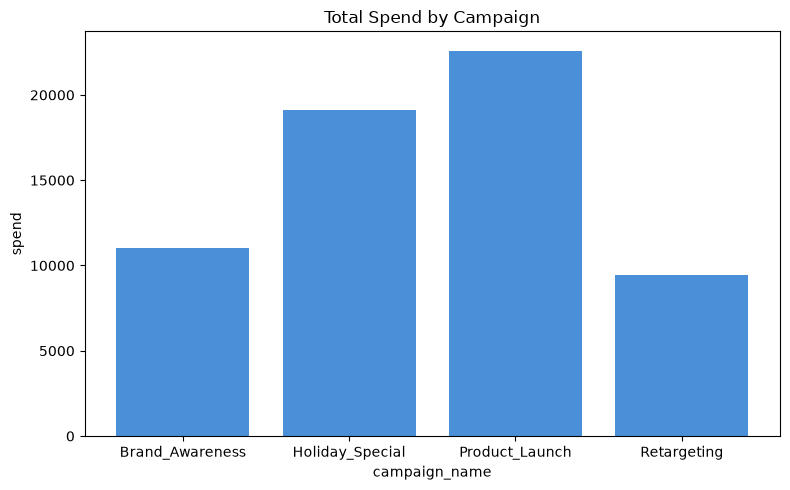

[Section 7.1 | Step 3] Saved bar chart to 'outputs/spend_by_campaign.png'.
[SUCCESS] plot_bar_chart completed. [Section 7.1]
[Section 7.1 | Step 2] Grouped 'clicks' by 'date' using 'sum'.
[SUCCESS] group_by_and_aggregate completed. [Section 7.1]
         date  clicks
0  2025-01-01   18500
1  2025-02-01   16600
2  2025-03-01   17900
3  2025-04-01   19400
4  2025-05-01   20700
5  2025-06-01   25300



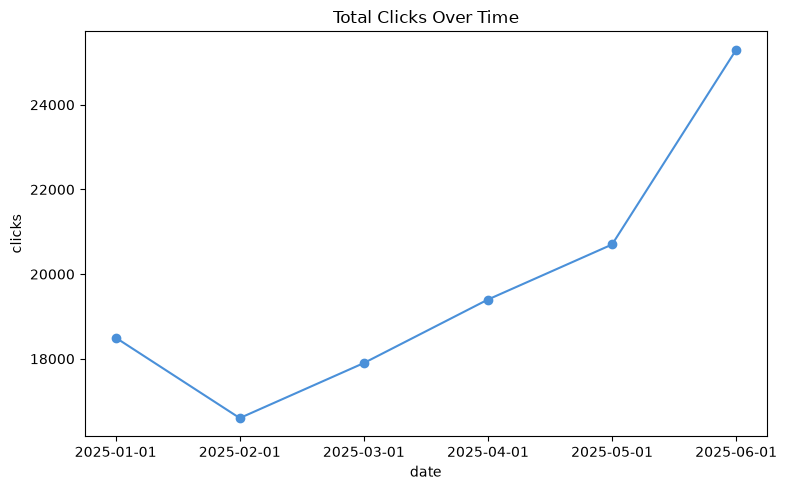

[Section 7.1 | Step 4] Saved line chart to 'outputs/clicks_over_time.png'.
[SUCCESS] plot_line_chart completed. [Section 7.1]
[SUCCESS] Section 1 Demo complete. Charts saved to outputs/.


In [6]:
# =============================================================================
# Section 1: Demo Pipeline — End-to-End Data Visualization
# Ref: Section 7.1, pp. 177–179 — Tool Chest composability
#
# Demonstrates the four tools working together in sequence:
#   1. load_csv → ingest the ad campaign dataset
#   2. group_by_and_aggregate → summarize spend by campaign
#   3. plot_bar_chart → render the bar chart
#   4. group_by_and_aggregate → summarize clicks over time
#   5. plot_line_chart → render the line chart
# =============================================================================

log_info("=" * 60)
log_info("Section 1 Demo: Data Visualization Pipeline")
log_info("=" * 60)

# Ensure outputs directory exists
os.makedirs("outputs", exist_ok=True)

# Step 1: Load the dataset
df = load_csv("data/sample_ad_campaign.csv")
if not df.empty:
    log_info(f"Dataset preview ({len(df)} rows):")
    print(df.head())
    print()

    # Step 2a: Aggregate spend by campaign (for bar chart)
    spend_by_campaign = group_by_and_aggregate(df, "campaign_name", "spend", "sum")
    if spend_by_campaign is not None:
        print(spend_by_campaign)
        print()
        # Step 3: Render bar chart
        plot_bar_chart(
            spend_by_campaign,
            "campaign_name", "spend",
            "Total Spend by Campaign",
            "outputs/spend_by_campaign.png",
        )

    # Step 2b: Aggregate clicks over time (for line chart)
    clicks_over_time = group_by_and_aggregate(df, "date", "clicks", "sum")
    if clicks_over_time is not None:
        print(clicks_over_time)
        print()
        # Step 4: Render line chart
        plot_line_chart(
            clicks_over_time,
            "date", "clicks",
            "Total Clicks Over Time",
            "outputs/clicks_over_time.png",
        )

    log_success("Section 1 Demo complete. Charts saved to outputs/.")
else:
    log_error("Dataset is empty. Cannot proceed with demo.")

---
## Section 2: Tool Discovery and Selection

**Chapter Reference:** Section 7.2 — Tool Discovery and Selection Algorithms

As an agent's tool chest grows, it must reliably select the correct tool for each task.
This section implements the first stage of the **Selection Funnel** (Figure 7.2):

1. **Intent Classification (broad filtering)** — Map the user's query to a relevant category
2. **Semantic Search (candidate ranking)** — Rank remaining tools by similarity (architectural)
3. **Constraint Filtering (final verification)** — Enforce input types, permissions, and status

The `parse_query` function below implements **template-based intent classification**,
the most direct approach where keywords map to structured parameters.

#### Figure 7.2 — Tool Selection Funnel *(Book p. 180)*

The multi-stage funnel transforms a large tool registry into a single verified, executable choice:

```
  All Available Tools (~100 tools)
         │
         ▼
  ┌──────────────────────────────┐
  │  1. Intent Classification    │ ──▶ ~20 tools
  │     Map query to categories  │
  └──────────────┬───────────────┘
                 ▼
  ┌──────────────────────────────┐
  │  2. Semantic Similarity      │ ──▶ ~5 tools
  │     Embedding-based ranking  │
  └──────────────┬───────────────┘
                 ▼
         Similarity > 0.7?
         Yes ▼      No → Discard
  ┌──────────────────────────────┐
  │  3. Constraint Filtering     │ ──▶ ~2-3 tools
  │     Input types, permissions │
  └──────────────┬───────────────┘
                 ▼
       ✓ Optimal Tool Selected
         (1 tool, ready to execute)
```


In [7]:
# =============================================================================
# Section 2: Intent Classification through Template Matching
# Ref: Section 7.2, pp. 182–183 — "Implementation Example: Intent Classification"
#
# parse_query() acts as a lightweight intent classifier. It scans for specific
# keywords and patterns to extract: a metric, a dimension, and a chart type.
# This implements the Template Matching selection strategy.
# =============================================================================

@graceful_fallback(fallback_return=None, section="7.2")
def parse_query(query: str) -> dict:
    """A simple natural language parser to extract intent from the user's query.
    Uses keyword matching to identify the metric, dimension, and chart type."""
    query = query.lower()  # Normalize for case-insensitive matching

    # --- Step 1: Identify the metric ---
    # A simple lookup to map known metric keywords to their column names
    metric_map = {"spend": "spend", "conversions": "conversions", "clicks": "clicks"}
    metric = next((metric_map[key] for key in metric_map if key in query), None)

    # --- Step 2: Identify the dimension and chart type ---
    # Use keywords to infer how the user wants to group and visualize data
    dimension, chart_type = None, None
    if "by campaign" in query or "which campaign" in query:
        dimension, chart_type = "campaign_name", "bar"
    elif "over time" in query or "trend" in query:
        dimension, chart_type = "date", "line"

    # --- Step 3: Validate and return the structured intent ---
    # If any essential component is missing, the intent is invalid
    if not all([metric, dimension, chart_type]):
        return None

    return {"metric": metric, "dimension": dimension, "chart_type": chart_type}


log_success("parse_query defined — template-matching intent classifier.")

[SUCCESS] parse_query defined — template-matching intent classifier.


In [8]:
# =============================================================================
# Section 2: Demo — Intent Classification on Sample Queries
# Ref: Section 7.2, p. 183 — "For a query like 'What was the trend of clicks
#       over time?', it identifies 'clicks' as the metric..."
# =============================================================================

log_info("=" * 60)
log_info("Section 2 Demo: Intent Classification")
log_info("=" * 60)

demo_queries = [
    "What was the trend of clicks over time?",
    "Show me spend by campaign",
    "Which campaign had the most conversions?",
    "Show me conversions over time",
    "Tell me something interesting",          # Should fail — no metric/dimension
    "What about clicks?",                     # Should fail — no dimension
]

for q in demo_queries:
    intent = parse_query(q)
    if intent:
        log_info(f"Query:  '{q}'")
        log_success(
            f"  → metric={intent['metric']}, "
            f"dimension={intent['dimension']}, "
            f"chart_type={intent['chart_type']}"
        )
    else:
        log_info(f"Query:  '{q}'")
        log_warning("  → Could not parse intent (missing metric or dimension).")
    print()

[INFO] ============================================================
[INFO] Section 2 Demo: Intent Classification
[INFO] ============================================================
[SUCCESS] parse_query completed. [Section 7.2]
[INFO] Query:  'What was the trend of clicks over time?'
[SUCCESS]   → metric=clicks, dimension=date, chart_type=line

[SUCCESS] parse_query completed. [Section 7.2]
[INFO] Query:  'Show me spend by campaign'
[SUCCESS]   → metric=spend, dimension=campaign_name, chart_type=bar

[SUCCESS] parse_query completed. [Section 7.2]
[INFO] Query:  'Which campaign had the most conversions?'
[SUCCESS]   → metric=conversions, dimension=campaign_name, chart_type=bar

[SUCCESS] parse_query completed. [Section 7.2]
[INFO] Query:  'Show me conversions over time'
[SUCCESS]   → metric=conversions, dimension=date, chart_type=line

[SUCCESS] parse_query completed. [Section 7.2]
[INFO] Query:  'Tell me something interesting'
[WARNING]   → Could not parse intent (missing metric or dim

> **📘 Implementation Insight: Failure Memory as Circuit Breaker** *(Book p. 184)*
>
> To prevent an agent from repeatedly attempting to use a tool that is clearly failing, the system can implement a short-term **failure memory**. This acts like a circuit breaker: if a tool fails multiple times in a short window, the agent temporarily marks it as unavailable and does not attempt to select it again for a predefined period, preventing wasted cycles.
>
> Production-ready agents implement a layered defense: **safe invocation wrappers** (try/except with retry logic), **fallback tool chains** (alternative tools for the same goal), **confidence-based switching** (discard low-confidence results and retry with a different tool), and **escalation paths** to human operators as the final fallback.


---
## Section 3: Error Handling and Resilience

**Chapter Reference:** Section 7.3 — Error Handling in Tool Integration

Production-ready agents implement a layered defense against four categories of failure:

1. **Input validation errors** — Data doesn't match the expected schema
2. **Runtime failures** — Network timeouts, API errors, file I/O exceptions
3. **Semantic mismatches** — Tool succeeds but produces the wrong result
4. **Tool unavailability** — External service is offline or deprecated

This section builds the `data_viz_agent` orchestrator, which ties together intent parsing,
tool selection, and error handling into a single **Think → Plan → Act** cycle.
It then demonstrates deliberate failure scenarios to show the resilience layer in action.

In [9]:
# =============================================================================
# Section 3: data_viz_agent — The Central Orchestrator
# Ref: Section 7.3, pp. 185–186 — "Implementation Example"
#
# This function implements the full Think/Plan/Act cycle:
#   THINK: parse_query() interprets the user's goal
#   PLAN:  Dynamically construct a list of tool calls based on intent
#   ACT:   Execute tools sequentially, passing data_state between steps
# =============================================================================

def data_viz_agent(query: str, file_path: str) -> Optional[str]:
    """Central orchestrator for the data visualization assistant.
    Implements the Think/Plan/Act cycle from Section 7.1."""

    log_info("=" * 60)
    log_step("7.3", 0, f"data_viz_agent received query: '{query}'")
    log_info("=" * 60)

    # ----- THINK: Interpret the user's goal -----
    log_step("7.3", 1, "THINK — Parsing user intent...")
    intent = parse_query(query)
    if intent is None:
        log_error("Could not understand the request. "
                  "Query must contain a metric (spend/clicks/conversions) "
                  "AND a dimension (by campaign / over time / trend).")
        return None

    log_info(f"  Intent Analysis: metric={intent['metric']}, "
             f"dimension={intent['dimension']}, chart_type={intent['chart_type']}")

    # ----- PLAN: Create a sequence of tool calls -----
    log_step("7.3", 2, "PLAN — Constructing execution plan...")
    plan = [
        ("load_csv", {"file_path": file_path}),
        ("group_by_and_aggregate", {
            "group_by_col": intent["dimension"],
            "agg_col": intent["metric"],
            "agg_func": "sum",
        }),
    ]

    if intent["chart_type"] == "bar":
        plot_tool = "plot_bar_chart"
        base_title = f"{intent['metric']} by {intent['dimension']}"
    else:
        plot_tool = "plot_line_chart"
        base_title = f"{intent['metric']} over {intent['dimension']}"

    output_path = f"outputs/output_{intent['metric']}_{intent['dimension']}.png"
    plan.append((plot_tool, {
        "x_col": intent["dimension"],
        "y_col": intent["metric"],
        "title": base_title,
        "output_path": output_path,
    }))

    log_info("  Action Plan:")
    for step_name, _ in plan:
        log_info(f"    - {step_name}")

    # ----- ACT: Execute the plan step-by-step -----
    log_step("7.3", 3, "ACT — Executing plan...")
    data_state = None

    tool_functions = {
        "load_csv": load_csv,
        "group_by_and_aggregate": group_by_and_aggregate,
        "plot_bar_chart": plot_bar_chart,
        "plot_line_chart": plot_line_chart,
    }

    for tool_name, tool_args in plan:
        tool_func = tool_functions[tool_name]

        # Inject data_state as the first argument for downstream tools
        if tool_name != "load_csv":
            tool_args["df"] = data_state

        result = tool_func(**tool_args)

        if isinstance(result, pd.DataFrame):
            if result.empty:
                log_error(f"Tool '{tool_name}' returned empty DataFrame. Aborting plan.")
                return None
            data_state = result
        elif result is None and tool_name != "load_csv":
            log_error(f"Execution failed at '{tool_name}'. Aborting plan.")
            return None

    log_success(f"data_viz_agent completed. Output: {output_path}")
    return output_path

[INFO] ============================================================
[INFO] Section 3 Demo: Successful Orchestration Runs
[INFO] ============================================================
[INFO] ============================================================
[Section 7.3 | Step 0] data_viz_agent received query: 'Show me spend by campaign'
[INFO] ============================================================
[Section 7.3 | Step 1] THINK — Parsing user intent...
[SUCCESS] parse_query completed. [Section 7.2]
[INFO]   Intent Analysis: metric=spend, dimension=campaign_name, chart_type=bar
[Section 7.3 | Step 2] PLAN — Constructing execution plan...
[INFO]   Action Plan:
[INFO]     - load_csv
[INFO]     - group_by_and_aggregate
[INFO]     - plot_bar_chart
[Section 7.3 | Step 3] ACT — Executing plan...
[Section 7.1 | Step 1] Loaded 24 rows from 'data/sample_ad_campaign.csv'.
[SUCCESS] load_csv completed. [Section 7.1]
[Section 7.1 | Step 2] Grouped 'spend' by 'campaign_name' using 'sum'.
[SUCCES

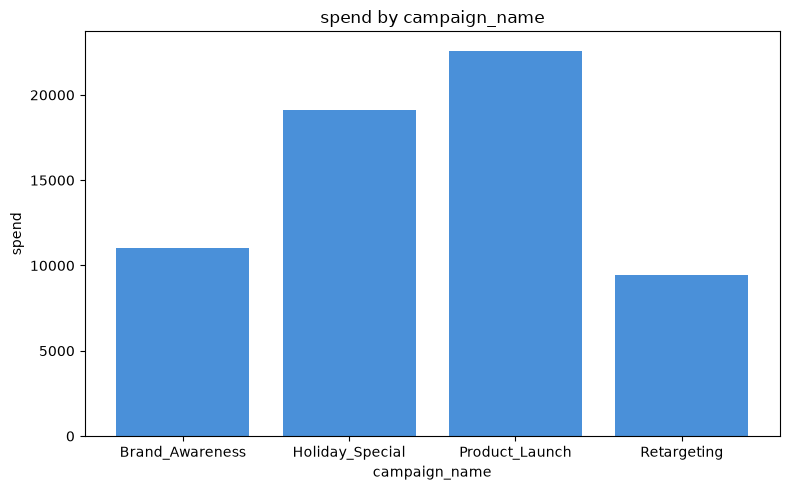

[Section 7.1 | Step 3] Saved bar chart to 'outputs/output_spend_campaign_name.png'.
[SUCCESS] plot_bar_chart completed. [Section 7.1]
[SUCCESS] data_viz_agent completed. Output: outputs/output_spend_campaign_name.png

[INFO] ============================================================
[Section 7.3 | Step 0] data_viz_agent received query: 'What was the trend of clicks over time?'
[INFO] ============================================================
[Section 7.3 | Step 1] THINK — Parsing user intent...
[SUCCESS] parse_query completed. [Section 7.2]
[INFO]   Intent Analysis: metric=clicks, dimension=date, chart_type=line
[Section 7.3 | Step 2] PLAN — Constructing execution plan...
[INFO]   Action Plan:
[INFO]     - load_csv
[INFO]     - group_by_and_aggregate
[INFO]     - plot_line_chart
[Section 7.3 | Step 3] ACT — Executing plan...
[Section 7.1 | Step 1] Loaded 24 rows from 'data/sample_ad_campaign.csv'.
[SUCCESS] load_csv completed. [Section 7.1]
[Section 7.1 | Step 2] Grouped 'clicks' b

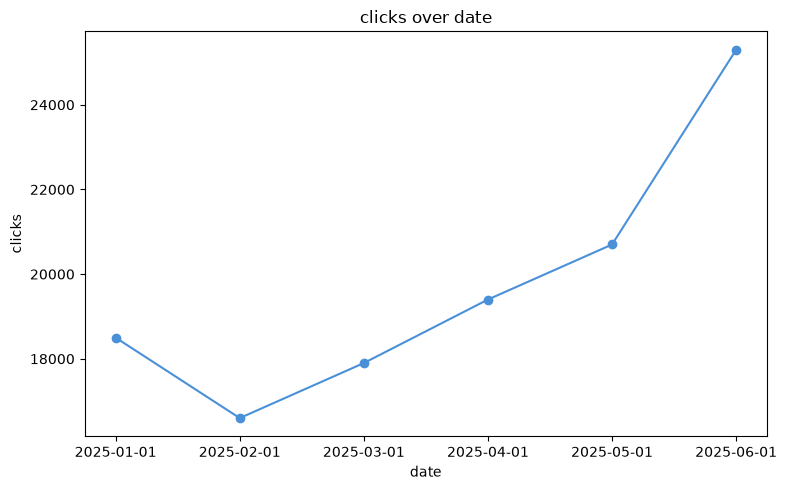

[Section 7.1 | Step 4] Saved line chart to 'outputs/output_clicks_date.png'.
[SUCCESS] plot_line_chart completed. [Section 7.1]
[SUCCESS] data_viz_agent completed. Output: outputs/output_clicks_date.png


'outputs/output_clicks_date.png'

In [10]:
# =============================================================================
# Section 3: Demo — Successful Orchestration
# Ref: Section 7.3 — data_viz_agent with valid queries
# =============================================================================

log_info("=" * 60)
log_info("Section 3 Demo: Successful Orchestration Runs")
log_info("=" * 60)

# Query 1: Bar chart of spend by campaign
data_viz_agent("Show me spend by campaign", "data/sample_ad_campaign.csv")
print()

# Query 2: Line chart of clicks over time
data_viz_agent("What was the trend of clicks over time?", "data/sample_ad_campaign.csv")

In [11]:
# =============================================================================
# Section 3: Deliberate Failure Demo 1 — FileNotFoundError
# Ref: Section 7.3, Strategy §6.6 — "Force FileNotFoundError"
#
# Expected behavior:
#   - load_csv catches FileNotFoundError
#   - Red [ERROR] log appears
#   - @graceful_fallback returns empty DataFrame
#   - Orchestrator detects df.empty and aborts cleanly
# =============================================================================

log_info("=" * 60)
log_warning("Section 3: DELIBERATE FAILURE DEMO — FileNotFoundError")
log_info("=" * 60)

result = data_viz_agent(
    "Show me spend by campaign",
    "nonexistent_file.csv",  # This file does not exist
)

if result is None:
    log_info("Orchestrator handled the failure gracefully. No crash.")

[INFO] ============================================================
[WARNING] Section 3: DELIBERATE FAILURE DEMO — FileNotFoundError
[INFO] ============================================================
[INFO] ============================================================
[Section 7.3 | Step 0] data_viz_agent received query: 'Show me spend by campaign'
[INFO] ============================================================
[Section 7.3 | Step 1] THINK — Parsing user intent...
[SUCCESS] parse_query completed. [Section 7.2]
[INFO]   Intent Analysis: metric=spend, dimension=campaign_name, chart_type=bar
[Section 7.3 | Step 2] PLAN — Constructing execution plan...
[INFO]   Action Plan:
[INFO]     - load_csv
[INFO]     - group_by_and_aggregate
[INFO]     - plot_bar_chart
[Section 7.3 | Step 3] ACT — Executing plan...
[ERROR] load_csv failed: [Errno 2] No such file or directory: 'nonexistent_file.csv'. Falling back. [Section 7.1]
[ERROR] Tool 'load_csv' returned empty DataFrame. Aborting plan.
[INFO

In [12]:
# =============================================================================
# Section 3: Deliberate Failure Demo 2 — Column Mismatch
# Ref: Section 7.3, Strategy §6.6 — "Force Column Mismatch"
#
# Expected behavior:
#   - group_by_and_aggregate detects invalid column "bad_column"
#   - Raises ValueError caught by @graceful_fallback
#   - Red [ERROR] log, returns None
#   - Orchestrator detects None and aborts cleanly
# =============================================================================

log_info("=" * 60)
log_warning("Section 3: DELIBERATE FAILURE DEMO — Column Mismatch")
log_info("=" * 60)

# First load a valid dataframe, then force a bad column name
df_valid = load_csv("data/sample_ad_campaign.csv")
if not df_valid.empty:
    bad_result = group_by_and_aggregate(df_valid, "bad_column", "spend", "sum")
    if bad_result is None:
        log_info("group_by_and_aggregate returned None for invalid column. "
                 "Orchestrator would abort cleanly at this point.")

log_success("Section 3 complete. Both failure demos handled gracefully.")

[INFO] ============================================================
[WARNING] Section 3: DELIBERATE FAILURE DEMO — Column Mismatch
[INFO] ============================================================
[Section 7.1 | Step 1] Loaded 24 rows from 'data/sample_ad_campaign.csv'.
[SUCCESS] load_csv completed. [Section 7.1]
[ERROR] group_by_and_aggregate failed: Column not found in DataFrame. Available: ['date', 'campaign_name', 'clicks', 'spend', 'conversions']. Falling back. [Section 7.1]
[INFO] group_by_and_aggregate returned None for invalid column. Orchestrator would abort cleanly at this point.
[SUCCESS] Section 3 complete. Both failure demos handled gracefully.


---
## Summary and Key Takeaways

- **Tool chest and registry (§7.1)** — four composable, single-responsibility tools with explicit schema contracts, cataloged in a central `TOOL_REGISTRY`.
- **Selection funnel (§7.2)** — `parse_query` implements template-matching intent classification, the first stage of the tool-selection funnel.
- **Think/Plan/Act cycle (§7.3)** — `data_viz_agent` interprets intent, constructs an execution plan, and executes tools sequentially while passing state between steps.
- **Layered resilience (§7.3)** — `@graceful_fallback` converts tool failures into logged, handled errors; the orchestrator aborts cleanly and no cell raises an unhandled exception.

**Book reference:** Chapter 7, Sections 7.1–7.3 (pp. 174–186) of *30 Agents Every AI Engineer Must Build* by Imran Ahmad (Packt Publishing, 2026). Sections 7.4–7.5 extend this single-agent foundation into the Chain-of-Agents Orchestrator.
